# Time Complexity Comparison: All 8 Models

This notebook compares inference-time complexity for 8 trained models:
- Random Forest
- Logistic Regression
- SVM
- KNN
- XGBoost
- CNN
- LSTM
- MLP

Only required analysis is included: empirical batch-time scaling, fitted complexity exponent, per-sample latency, throughput, and saved outputs.

In [7]:
import warnings
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Resolve paths robustly (works from notebook dir or workspace root)
candidate_roots = [
    Path.cwd(),
    Path.cwd() / 'ML',
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

models_dir = None
dataset_path = None
for root in candidate_roots:
    m = (root / 'models')
    d1 = (root / 'Synthetic_Data' / 'synthetic_foot_ulcer_dataset_RISK.csv')
    d2 = (root.parent / 'Synthetic_Data' / 'synthetic_foot_ulcer_dataset_RISK.csv')
    if m.exists() and (d1.exists() or d2.exists()):
        models_dir = m
        dataset_path = d1 if d1.exists() else d2
        break

if models_dir is None:
    # Explicit fallback for repo structure: ML/Analysis
    models_dir = Path('../models').resolve()
    dataset_path = Path('../../Synthetic_Data/synthetic_foot_ulcer_dataset_RISK.csv').resolve()

# Save all outputs under ML/Analysis/FINAL_COMPARISON
output_dir = (Path.cwd() / 'FINAL_COMPARISON').resolve()
output_dir.mkdir(exist_ok=True, parents=True)

print(f'Models dir:  {models_dir.resolve()}')
print(f'Dataset:     {dataset_path.resolve()}')
print(f'Output dir:  {output_dir.resolve()}')

# Load and prepare dataset
df = pd.read_csv(dataset_path)

TEMP_FEATURES = ['temp_heel', 'temp_ball', 'temp_arch', 'temp_toe']
PRESSURE_FEATURES = ['press_heel', 'press_ball', 'press_arch', 'press_toe']
VITAL_FEATURES = ['spo2', 'heartRate']
ACTIVITY_FEATURES = ['stepCount']
ENGINEERED_FEATURES = ['max_pressure', 'pressure_variance', 'max_temp', 'temp_variance']

RAW_19_FEATURES = [
    'temp_heel', 'press_heel', 'temp_ball', 'press_ball',
    'temp_arch', 'press_arch', 'temp_toe', 'press_toe',
    'spo2', 'heartRate', 'acc_x', 'acc_y', 'acc_z',
    'gyro_x', 'gyro_y', 'gyro_z', 'stepCount', 'batteryLevel', 'risk_score'
]
FEAT_15 = TEMP_FEATURES + PRESSURE_FEATURES + VITAL_FEATURES + ACTIVITY_FEATURES + ENGINEERED_FEATURES

df_proc = df.copy()
df_proc['max_pressure'] = df_proc[PRESSURE_FEATURES].max(axis=1)
df_proc['pressure_variance'] = df_proc[PRESSURE_FEATURES].var(axis=1)
df_proc['max_temp'] = df_proc[TEMP_FEATURES].max(axis=1)
df_proc['temp_variance'] = df_proc[TEMP_FEATURES].var(axis=1)

print(f'Rows available: {len(df_proc)}')
print('Setup complete.')

Models dir:  E:\S4\WORKING\neurosocks-ai\ML\models
Dataset:     E:\S4\WORKING\neurosocks-ai\Synthetic_Data\synthetic_foot_ulcer_dataset_RISK.csv
Output dir:  E:\S4\WORKING\neurosocks-ai\ML\Analysis\FINAL_COMPARISON
Rows available: 10000
Setup complete.


In [9]:
# Load all model artifacts using the confirmed project structure
def resolve_existing_path(*candidates):
    for c in candidates:
        p = Path(c)
        if p.exists():
            return p
    raise FileNotFoundError(f'None of these paths exist: {candidates}')

class CompatibleLSTM(tf.keras.layers.LSTM):
    """Keras compatibility shim for legacy models that store unsupported args."""
    def __init__(self, *args, **kwargs):
        kwargs.pop('time_major', None)
        super().__init__(*args, **kwargs)

def load_keras_model_robust(primary_path, extra_candidates=None):
    """Load keras model with fallbacks for mixed/legacy formats."""
    import shutil
    candidates = [Path(primary_path)]
    if extra_candidates:
        candidates.extend([Path(p) for p in extra_candidates])

    custom_objects = {'LSTM': CompatibleLSTM}
    errors = []
    for p in candidates:
        if not p.exists():
            continue
        try:
            return tf.keras.models.load_model(p, compile=False, custom_objects=custom_objects)
        except Exception as e:
            errors.append(f'{p}: {e}')

            # If mislabeled legacy HDF5 with .keras extension, duplicate as .h5 and retry
            if p.suffix == '.keras':
                try:
                    import h5py
                    if h5py.is_hdf5(str(p)):
                        temp_h5 = p.with_suffix('.autofix_load.h5')
                        shutil.copy2(p, temp_h5)
                        try:
                            model = tf.keras.models.load_model(
                                temp_h5,
                                compile=False,
                                custom_objects=custom_objects
                            )
                            temp_h5.unlink(missing_ok=True)
                            return model
                        finally:
                            if temp_h5.exists():
                                temp_h5.unlink(missing_ok=True)
                except Exception as h5e:
                    errors.append(f'{p} (hdf5 fallback): {h5e}')

    raise RuntimeError('Failed to load keras model. Details:\n' + '\n'.join(errors))

# Root-level model files (outside subfolders)
rf_path = resolve_existing_path(models_dir / 'random_forest_model.pkl')
svm_path = resolve_existing_path(models_dir / 'svm_model.pkl')
cnn_path = resolve_existing_path(
    models_dir / 'cnn_model.keras',
    models_dir / 'cnn_model.h5'
 )

# Folder-level model files
lr_path = resolve_existing_path(models_dir / 'LR' / 'logistic_regression_model.pkl')
knn_path = resolve_existing_path(models_dir / 'KNN' / 'knn_model.pkl')
lstm_path = resolve_existing_path(models_dir / 'LSTM' / 'lstm_model.keras')
mlp_path = resolve_existing_path(models_dir / 'MLP' / 'mlp_model.keras')
xgb_path = resolve_existing_path(
    models_dir / 'XG_Boost' / 'xgboost_model.pkl',
    models_dir / 'XG_Boost' / 'xgboost_model.json'
 )

models = {
    'Random Forest': {
        'type': 'sklearn',
        'model': joblib.load(rf_path),
        'scaler_candidates': [models_dir / 'scaler.pkl']
    },
    'Logistic Regression': {
        'type': 'sklearn',
        'model': joblib.load(lr_path),
        'scaler_candidates': [models_dir / 'LR' / 'scaler.pkl']
    },
    'SVM': {
        'type': 'sklearn',
        'model': joblib.load(svm_path),
        'scaler_candidates': [models_dir / 'scaler.pkl']
    },
    'KNN': {
        'type': 'sklearn',
        'model': joblib.load(knn_path),
        'scaler_candidates': [models_dir / 'KNN' / 'scaler.pkl']
    },
    'XGBoost': {
        'type': 'sklearn',
        'model': joblib.load(xgb_path) if xgb_path.suffix == '.pkl' else None,
        'scaler_candidates': [models_dir / 'XG_Boost' / 'scaler.pkl']
    },
    'CNN': {
        'type': 'keras_cnn',
        'model': load_keras_model_robust(
            cnn_path,
            [models_dir / 'cnn_model.h5', models_dir / 'cnn_model.keras']
        ),
        'scaler_candidates': [models_dir / 'cnn_scaler.pkl']
    },
    'LSTM': {
        'type': 'keras_lstm',
        'model': load_keras_model_robust(
            lstm_path,
            [models_dir / 'LSTM' / 'lstm_model.h5', models_dir / 'LSTM' / 'lstm_model.keras']
        ),
        'scaler_candidates': [models_dir / 'LSTM' / 'scaler.pkl']
    },
    'MLP': {
        'type': 'keras_mlp',
        'model': load_keras_model_robust(
            mlp_path,
            [models_dir / 'MLP' / 'mlp_model.h5', models_dir / 'MLP' / 'mlp_model.keras']
        ),
        'scaler_candidates': [models_dir / 'MLP' / 'scaler.pkl']
    },
}

# If XGBoost model is JSON, load via xgboost API
if models['XGBoost']['model'] is None:
    import xgboost as xgb
    xgb_model = xgb.XGBClassifier()
    xgb_model.load_model(str(xgb_path))
    models['XGBoost']['model'] = xgb_model

print('Model paths resolved:')
print(f'  RF:   {rf_path}')
print(f'  SVM:  {svm_path}')
print(f'  CNN:  {cnn_path}')
print(f'  LR:   {lr_path}')
print(f'  KNN:  {knn_path}')
print(f'  XGB:  {xgb_path}')
print(f'  LSTM: {lstm_path}')
print(f'  MLP:  {mlp_path}')

def get_expected_features(model_info):
    m = model_info['model']
    if model_info['type'] == 'sklearn':
        return int(getattr(m, 'n_features_in_', 15))
    if model_info['type'] == 'keras_cnn':
        # (None, n_features, 1)
        return int(m.input_shape[1])
    if model_info['type'] == 'keras_lstm':
        # (None, seq_len, n_features)
        return int(m.input_shape[2])
    if model_info['type'] == 'keras_mlp':
        # (None, n_features)
        return int(m.input_shape[1])
    return 15

def select_feature_matrix(expected_n_features):
    if expected_n_features == len(FEAT_15):
        return df_proc[FEAT_15].values, FEAT_15
    if expected_n_features == len(RAW_19_FEATURES):
        return df_proc[RAW_19_FEATURES].values, RAW_19_FEATURES
    # Fallback: use first N numeric columns
    numeric_cols = [c for c in df_proc.columns if c != 'label']
    cols = numeric_cols[:expected_n_features]
    return df_proc[cols].values, cols

def load_best_scaler(candidates):
    for p in candidates:
        if p.exists():
            return joblib.load(p), str(p)
    return None, None

prepared = {}
for name, info in models.items():
    expected = get_expected_features(info)
    X_raw, cols = select_feature_matrix(expected)

    scaler, scaler_path = load_best_scaler(info['scaler_candidates'])
    if scaler is not None and hasattr(scaler, 'n_features_in_') and int(scaler.n_features_in_) == X_raw.shape[1]:
        X_scaled = scaler.transform(X_raw)
        scaler_used = scaler_path
    else:
        fallback_scaler = StandardScaler()
        X_scaled = fallback_scaler.fit_transform(X_raw)
        scaler_used = 'fallback(StandardScaler fit on current data)'

    prepared[name] = {
        'type': info['type'],
        'model': info['model'],
        'X_scaled': X_scaled.astype(np.float32),
        'expected_features': expected,
        'feature_count': X_raw.shape[1],
        'feature_names': cols,
        'scaler_used': scaler_used,
    }

summary_rows = []
for name, p in prepared.items():
    summary_rows.append([name, p['type'], p['feature_count'], p['scaler_used']])

print(pd.DataFrame(summary_rows, columns=['Model', 'Type', 'Feature Count', 'Scaler Used']).to_string(index=False))

Model paths resolved:
  RF:   e:\S4\WORKING\neurosocks-ai\ML\models\random_forest_model.pkl
  SVM:  e:\S4\WORKING\neurosocks-ai\ML\models\svm_model.pkl
  CNN:  e:\S4\WORKING\neurosocks-ai\ML\models\cnn_model.keras
  LR:   e:\S4\WORKING\neurosocks-ai\ML\models\LR\logistic_regression_model.pkl
  KNN:  e:\S4\WORKING\neurosocks-ai\ML\models\KNN\knn_model.pkl
  XGB:  e:\S4\WORKING\neurosocks-ai\ML\models\XG_Boost\xgboost_model.pkl
  LSTM: e:\S4\WORKING\neurosocks-ai\ML\models\LSTM\lstm_model.keras
  MLP:  e:\S4\WORKING\neurosocks-ai\ML\models\MLP\mlp_model.keras
              Model       Type  Feature Count                                               Scaler Used
      Random Forest    sklearn             15              fallback(StandardScaler fit on current data)
Logistic Regression    sklearn             15       e:\S4\WORKING\neurosocks-ai\ML\models\LR\scaler.pkl
                SVM    sklearn             19              fallback(StandardScaler fit on current data)
                KNN 

In [10]:
# Time complexity benchmarking
def time_predict(predict_fn, X_input, n_runs=10):
    # Warmup
    _ = predict_fn(X_input)
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        _ = predict_fn(X_input)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return float(np.mean(times)), float(np.std(times))

def estimate_exponent(n_vals, t_vals):
    n = np.asarray(n_vals, dtype=float)
    t = np.asarray(t_vals, dtype=float)
    mask = (n > 0) & (t > 0)
    coef = np.polyfit(np.log(n[mask]), np.log(t[mask]), 1)
    return float(coef[0])

batch_sizes = [50, 100, 250, 500, 1000, 2000, 4000, 8000]

def make_predict_input(model_name, p, batch_size):
    X = p['X_scaled']
    mtype = p['type']
    if mtype == 'sklearn' or mtype == 'keras_mlp':
        return X[:batch_size]
    if mtype == 'keras_cnn':
        x = X[:batch_size]
        return x.reshape(x.shape[0], x.shape[1], 1)
    if mtype == 'keras_lstm':
        seq_len = int(p['model'].input_shape[1])
        n_feat = int(p['model'].input_shape[2])
        needed = batch_size + seq_len - 1
        base = X[:needed, :n_feat]
        seq = np.array([base[i:i+seq_len] for i in range(batch_size)], dtype=np.float32)
        return seq
    return X[:batch_size]

def make_predict_fn(p):
    model = p['model']
    if p['type'].startswith('keras'):
        return lambda x: model.predict(x, verbose=0)
    return lambda x: model.predict(x)

records = []
for model_name, p in prepared.items():
    predict_fn = make_predict_fn(p)
    for bs in batch_sizes:
        x_in = make_predict_input(model_name, p, bs)
        mean_t, std_t = time_predict(predict_fn, x_in, n_runs=10)
        records.append({
            'model': model_name,
            'batch_size': bs,
            'mean_time_sec': mean_t,
            'std_time_sec': std_t,
            'time_ms': mean_t * 1000.0,
            'latency_us_per_sample': (mean_t / bs) * 1_000_000.0,
            'throughput_pred_per_sec': bs / mean_t if mean_t > 0 else np.nan,
        })

results_df = pd.DataFrame(records)

theoretical_map = {
    'Random Forest': 'O(T*depth)',
    'Logistic Regression': 'O(m)',
    'SVM': 'O(n_sv*m)',
    'KNN': 'O(n_train*m)',
    'XGBoost': 'O(T*depth)',
    'CNN': 'O(conv_ops)',
    'LSTM': 'O(seq_len*(h^2+h*m))',
    'MLP': 'O(sum layer multiplications)',
}

summary = []
for model_name in results_df['model'].unique():
    sub = results_df[results_df['model'] == model_name].sort_values('batch_size')
    exp = estimate_exponent(sub['batch_size'].values, sub['mean_time_sec'].values)
    row_8k = sub[sub['batch_size'] == 8000].iloc[0]
    summary.append({
        'model': model_name,
        'theoretical_inference_complexity': theoretical_map.get(model_name, 'N/A'),
        'empirical_scaling': f'O(n^{exp:.3f})',
        'fitted_exponent': exp,
        'latency_us_per_sample_at_8000': row_8k['latency_us_per_sample'],
        'throughput_pred_per_sec_at_8000': row_8k['throughput_pred_per_sec'],
        'time_ms_at_8000': row_8k['time_ms'],
    })

summary_df = pd.DataFrame(summary).sort_values('latency_us_per_sample_at_8000')

print('✅ Benchmark complete for all 8 models')
print(summary_df[['model', 'empirical_scaling', 'latency_us_per_sample_at_8000', 'throughput_pred_per_sec_at_8000']].to_string(index=False))

✅ Benchmark complete for all 8 models
              model empirical_scaling  latency_us_per_sample_at_8000  throughput_pred_per_sec_at_8000
Logistic Regression        O(n^0.391)                       0.192105                     5.205487e+06
            XGBoost        O(n^0.188)                       0.573249                     1.744443e+06
      Random Forest        O(n^0.076)                      10.814080                     9.247204e+04
                MLP        O(n^0.315)                      88.736122                     1.126937e+04
                KNN        O(n^0.641)                     112.225981                     8.910593e+03
               LSTM        O(n^0.463)                     136.870161                     7.306194e+03
                SVM        O(n^0.961)                     208.546205                     4.795100e+03
                CNN        O(n^0.468)                     251.262631                     3.979899e+03


In [11]:
# Save required outputs in Analysis/FINAL_COMPARISON
results_csv = output_dir / 'all_models_time_complexity_results.csv'
summary_csv = output_dir / 'all_models_time_complexity_summary.csv'

results_df.to_csv(results_csv, index=False)
summary_df.to_csv(summary_csv, index=False)

print(f'✅ Saved: {results_csv.resolve()}')
print(f'✅ Saved: {summary_csv.resolve()}')

✅ Saved: E:\S4\WORKING\neurosocks-ai\ML\Analysis\FINAL_COMPARISON\all_models_time_complexity_results.csv
✅ Saved: E:\S4\WORKING\neurosocks-ai\ML\Analysis\FINAL_COMPARISON\all_models_time_complexity_summary.csv


✅ Saved: E:\S4\WORKING\neurosocks-ai\ML\Analysis\FINAL_COMPARISON\all_models_time_complexity_comparison.png


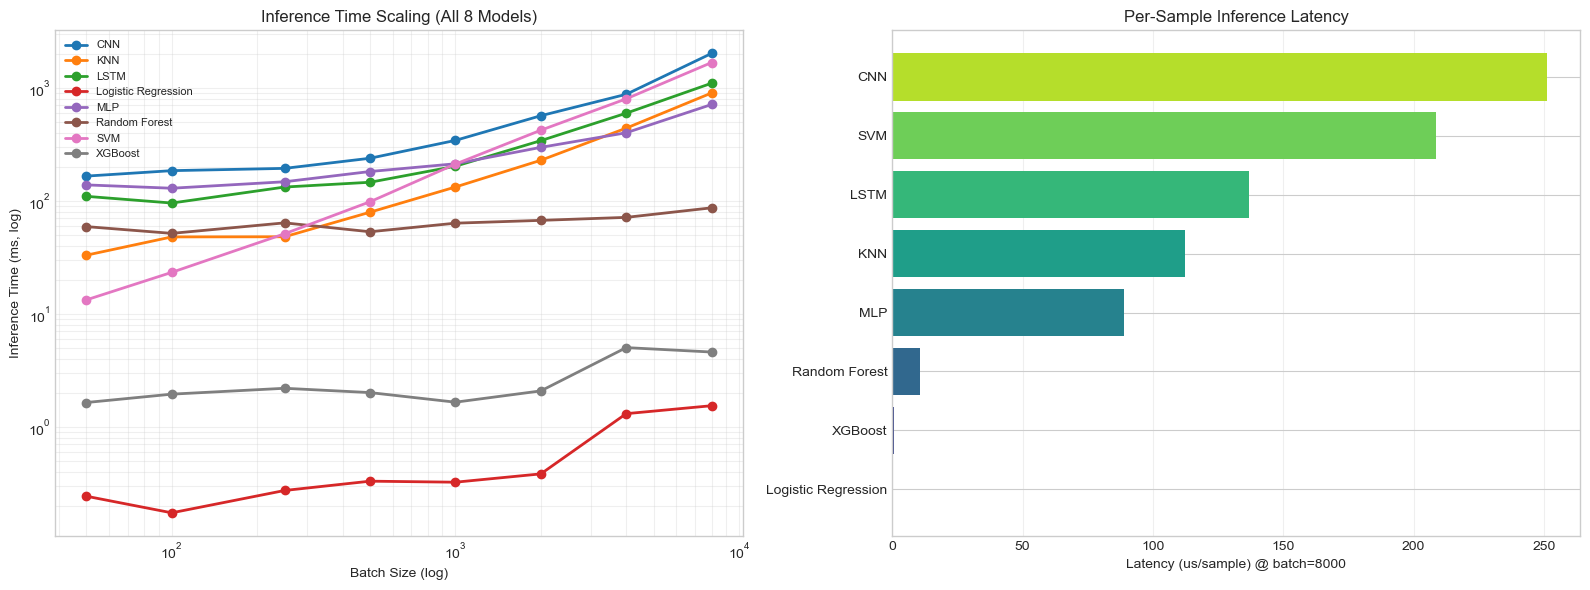


Top models by lowest latency (us/sample):


,model,theoretical_inference_complexity,empirical_scaling,latency_us_per_sample_at_8000,throughput_pred_per_sec_at_8000
1,Logistic Regression,O(m),O(n^0.391),0.192105,5.205487e+06
4,XGBoost,O(T*depth),O(n^0.188),0.573249,1.744443e+06
0,Random Forest,O(T*depth),O(n^0.076),10.814080,9.247204e+04
7,MLP,O(sum layer multiplications),O(n^0.315),88.736122,1.126937e+04
3,KNN,O(n_train*m),O(n^0.641),112.225981,8.910593e+03
6,LSTM,O(seq_len*(h^2+h*m)),O(n^0.463),136.870161,7.306194e+03
2,SVM,O(n_sv*m),O(n^0.961),208.546205,4.795100e+03
5,CNN,O(conv_ops),O(n^0.468),251.262631,3.979899e+03


In [12]:
# Required visual outputs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Inference time vs batch size (log-log)
for model_name, sub in results_df.groupby('model'):
    sub = sub.sort_values('batch_size')
    axes[0].loglog(sub['batch_size'], sub['time_ms'], marker='o', linewidth=2, label=model_name)
axes[0].set_xlabel('Batch Size (log)')
axes[0].set_ylabel('Inference Time (ms, log)')
axes[0].set_title('Inference Time Scaling (All 8 Models)')
axes[0].grid(True, which='both', alpha=0.3)
axes[0].legend(fontsize=8)

# Plot 2: Per-sample latency at batch=8000
lat = summary_df.sort_values('latency_us_per_sample_at_8000')
axes[1].barh(lat['model'], lat['latency_us_per_sample_at_8000'], color=sns.color_palette('viridis', len(lat)))
axes[1].set_xlabel('Latency (us/sample) @ batch=8000')
axes[1].set_title('Per-Sample Inference Latency')
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plot_path = output_dir / 'all_models_time_complexity_comparison.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f'✅ Saved: {plot_path.resolve()}')
plt.show()

print('\nTop models by lowest latency (us/sample):')
display(summary_df[['model', 'theoretical_inference_complexity', 'empirical_scaling', 'latency_us_per_sample_at_8000', 'throughput_pred_per_sec_at_8000']].sort_values('latency_us_per_sample_at_8000'))